In [16]:
import sys
sys.path.append('..')

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from src.data_loader import load_data

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False 


In [18]:
df = load_data()
df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,BF9B45EF846F766F,electric_bike,2025-04-05 15:18:25.360,2025-04-05 15:32:07.818,111 St & 53 Ave,6171.02,Broadway & 74 St,6332.10,40.743360,-73.851290,40.746530,-73.891210,casual
1,019D3C58B9CCA0AD,electric_bike,2025-04-02 08:58:40.957,2025-04-02 09:04:59.729,E 27 St & 1 Ave,6004.06,E 40 St & Park Ave,6432.11,40.739445,-73.976806,40.750756,-73.978326,member
2,5E68E6942DE381BD,classic_bike,2025-04-08 11:58:27.583,2025-04-08 12:06:55.120,W 113 St & Broadway,7713.01,Frederick Douglass Blvd & W 117 St,7688.12,40.805973,-73.964928,40.805159,-73.954692,member
3,801EAB661E50A4C1,electric_bike,2025-04-01 09:48:58.509,2025-04-01 09:53:00.136,Lexington Ave & E 26 St,6089.08,E 40 St & Park Ave,6432.11,40.741459,-73.983293,40.750756,-73.978326,member
4,ED609B115FB559EC,electric_bike,2025-04-09 11:15:45.418,2025-04-09 11:25:51.783,Bedford Park Blvd & Paul Ave,8752.01,Jerome Ave & E Mosholu Pkwy S,8795.01,40.874440,-73.891860,40.879350,-73.885340,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28206522,159C184B4F4FE40B,electric_bike,2025-09-15 06:59:06.215,2025-09-15 07:09:35.603,W 21 St & 6 Ave,6140.05,E 56 St & Madison Ave,6732.01,40.741740,-73.994156,40.761573,-73.972628,member
28206523,6E511655F2115D09,electric_bike,2025-09-23 18:22:54.717,2025-09-23 18:42:38.748,W 21 St & 6 Ave,6140.05,W 44 St & 11 Ave,6756.05,40.741740,-73.994156,40.762009,-73.996975,member
28206524,92D2EBF17AD9C5BC,electric_bike,2025-09-18 17:11:08.407,2025-09-18 17:21:27.157,W 51 St & 6 Ave,6740.10,E 77 St & 3 Ave,7092.06,40.760660,-73.980420,40.773142,-73.958562,member
28206525,55BA0B48F186855F,classic_bike,2025-09-16 20:21:43.034,2025-09-16 20:24:51.574,Davis St & Jackson Ave,6278.05,21 St & 43 Ave,6395.01,40.745627,-73.945661,40.750525,-73.945948,casual


In [19]:
print(df.shape)
print(df.dtypes)

(28206527, 13)
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object


In [20]:
df.describe(include='all')

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
count,28206527,28206527,28206527,28206527,28194223,28206527,28124288,28206527,2.819422e+07,2.819422e+07,2.812105e+07,2.812105e+07,28206527
unique,28206527,2,28162788,28163655,2180,2281,2263,2364,NaN,NaN,NaN,NaN,2
top,3E2A615F32BA1874,electric_bike,2025-06-13 13:47:44.681,2025-07-26 07:28:31.941,W 21 St & 6 Ave,6140.05,W 21 St & 6 Ave,6140.05,NaN,NaN,NaN,NaN,member
freq,1,19789682,3,28,97244,97244,97359,97357,NaN,NaN,NaN,NaN,22586330
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.073672e+01,-7.397170e+01,4.073654e+01,-7.397178e+01,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.040610e-02,2.889403e-02,4.316914e-02,4.018186e-02,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.063338e+01,-7.403699e+01,0.000000e+00,-7.408670e+01,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.071255e+01,-7.399209e+01,4.071255e+01,-7.399233e+01,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.073535e+01,-7.397907e+01,4.073524e+01,-7.397907e+01,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.076018e+01,-7.395509e+01,4.076009e+01,-7.395516e+01,NaN


In [21]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at']   = pd.to_datetime(df['ended_at'])

print(f"데이터 기간: {df['started_at'].min()} ~ {df['started_at'].max()}")

데이터 기간: 2025-03-31 02:22:50.612000 ~ 2025-09-30 23:58:26.908000


In [22]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '결측치 수': missing,
    '결측률 (%)': missing_pct
}).sort_values('결측치 수', ascending=False)

print(missing_df)


                    결측치 수  결측률 (%)
end_lng             85476     0.30
end_lat             85476     0.30
end_station_name    82239     0.29
start_lat           12304     0.04
start_station_name  12304     0.04
start_lng           12304     0.04
started_at              0     0.00
rideable_type           0     0.00
ride_id                 0     0.00
ended_at                0     0.00
start_station_id        0     0.00
end_station_id          0     0.00
member_casual           0     0.00


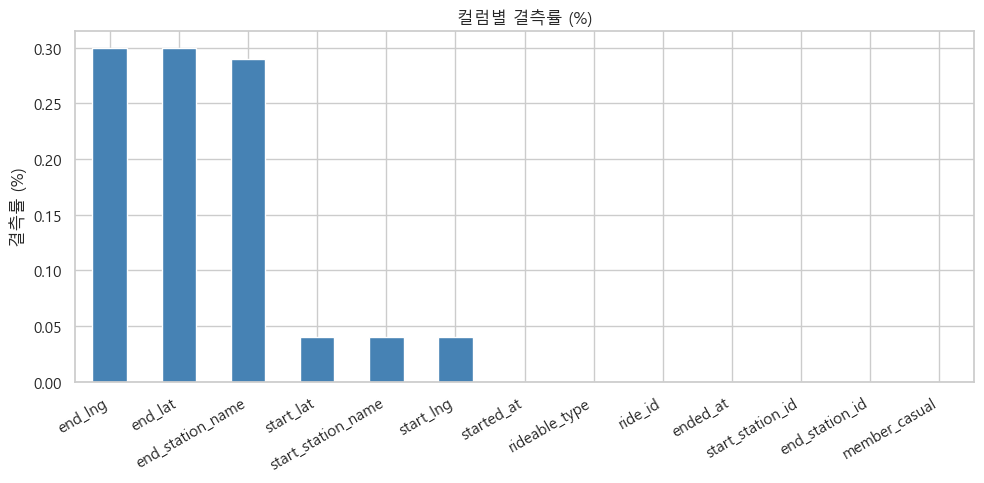

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['결측률 (%)'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('컬럼별 결측률 (%)')
ax.set_ylabel('결측률 (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

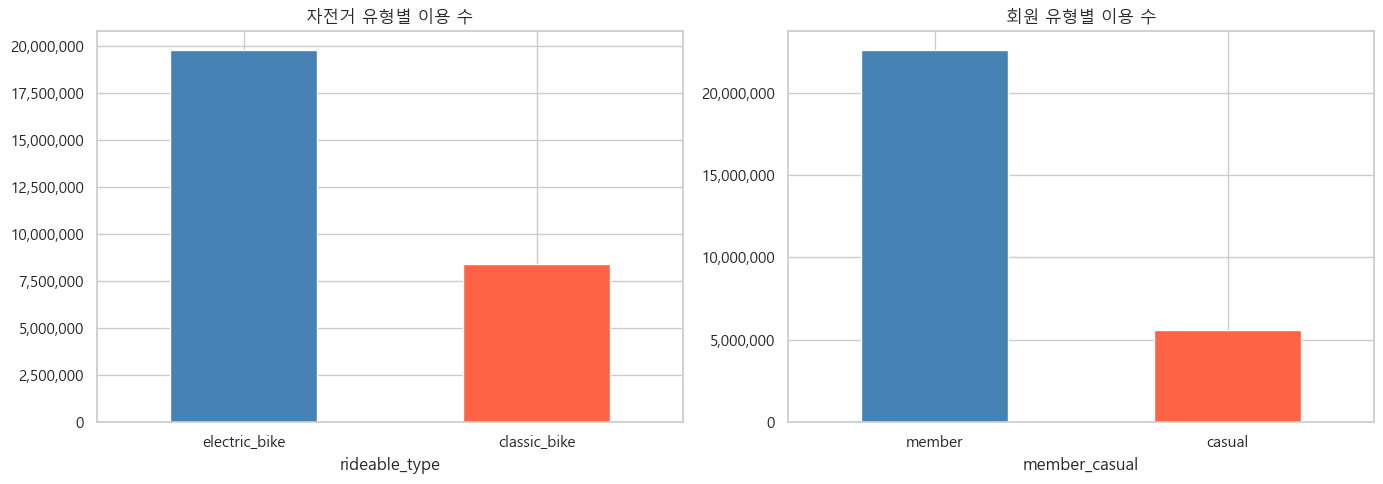

자전거 유형 비율:
rideable_type
electric_bike    70.16
classic_bike     29.84
Name: count, dtype: float64

회원 유형 비율:
member_casual
member    80.07
casual    19.93
Name: count, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rt_counts = df['rideable_type'].value_counts()
rt_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato', 'seagreen'], edgecolor='white')
axes[0].set_title('자전거 유형별 이용 수')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=0)

mc_counts = df['member_casual'].value_counts()
mc_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('회원 유형별 이용 수')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('자전거 유형 비율:')
print((rt_counts / len(df) * 100).round(2))
print('\n회원 유형 비율:')
print((mc_counts / len(df) * 100).round(2))

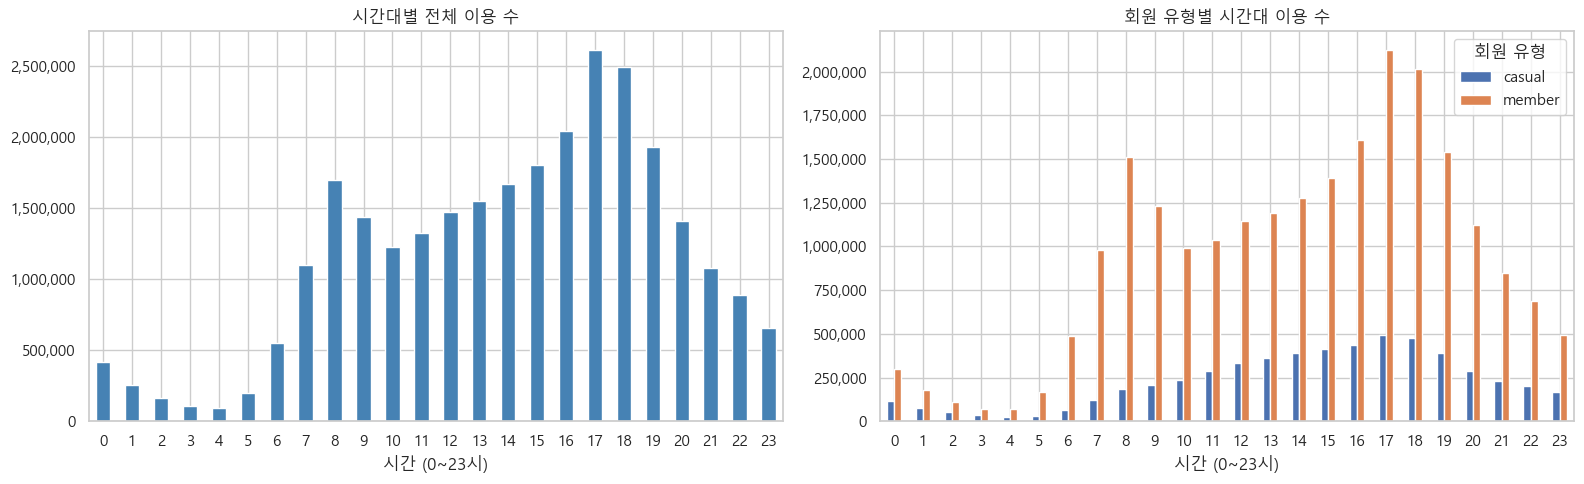

In [25]:
df['hour'] = df['started_at'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hourly = df.groupby('hour').size()
hourly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('시간대별 전체 이용 수')
axes[0].set_xlabel('시간 (0~23시)')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=0)

hourly_member = df.groupby(['hour', 'member_casual']).size().unstack()
hourly_member.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('회원 유형별 시간대 이용 수')
axes[1].set_xlabel('시간 (0~23시)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='회원 유형')

plt.tight_layout()
plt.show()

=== duration_min 기본 통계 ===
count    28206527.00
mean           13.71
std            30.46
min             0.28
25%             5.44
50%             9.38
75%            16.24
max         14629.41
Name: duration_min, dtype: float64

음수 duration 수: 0
60분 초과 비율:   1.12%


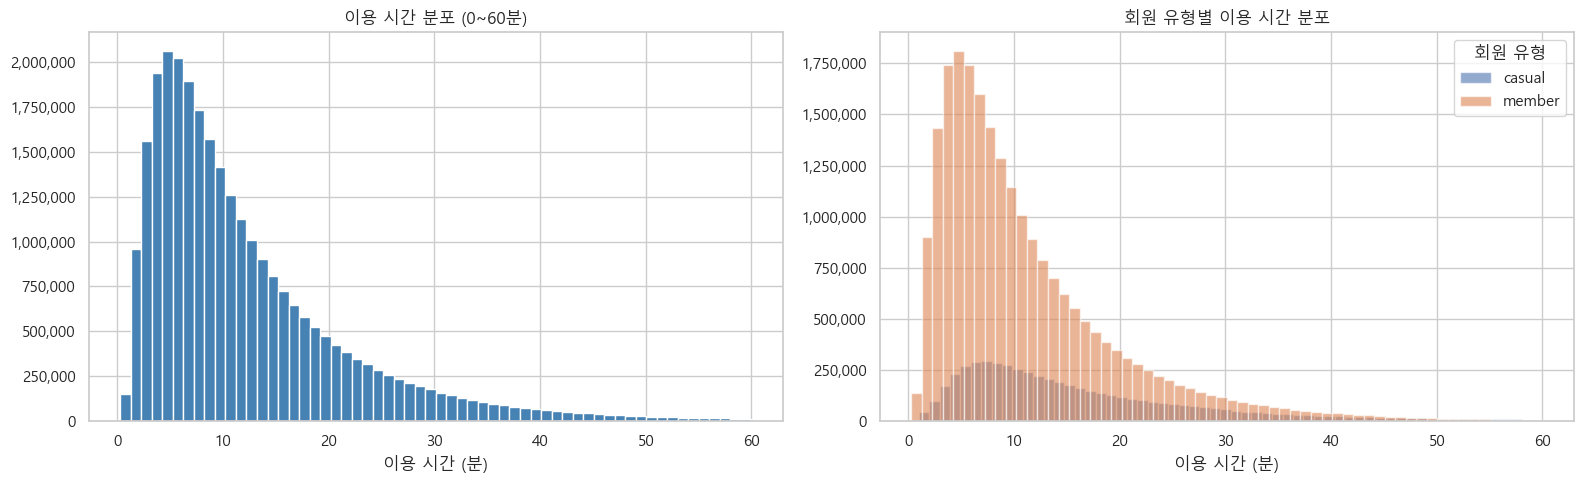

In [26]:
df['duration_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

print('=== duration_min 기본 통계 ===')
print(df['duration_min'].describe().round(2))
print(f"\n음수 duration 수: {(df['duration_min'] < 0).sum():,}")
print(f"60분 초과 비율:   {(df['duration_min'] > 60).mean() * 100:.2f}%")

dur_filtered = df[(df['duration_min'] > 0) & (df['duration_min'] <= 60)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dur_filtered['duration_min'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('이용 시간 분포 (0~60분)')
axes[0].set_xlabel('이용 시간 (분)')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for label, grp in dur_filtered.groupby('member_casual'):
    grp['duration_min'].hist(bins=60, ax=axes[1], alpha=0.6, label=label, edgecolor='white')
axes[1].set_title('회원 유형별 이용 시간 분포')
axes[1].set_xlabel('이용 시간 (분)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].legend(title='회원 유형')

plt.tight_layout()
plt.show()

In [27]:
print(f"음수 duration      : {(df['duration_min'] < 0).sum():,} 건")
print(f"duration = 0       : {(df['duration_min'] == 0).sum():,} 건")
print(f"duration > 180분   : {(df['duration_min'] > 180).sum():,} 건")

lat_out = df[(df['start_lat'] < 40.4) | (df['start_lat'] > 41.0)]
lng_out = df[(df['start_lng'] < -74.3) | (df['start_lng'] > -73.6)]
print(f"\nstart_lat 범위 초과: {len(lat_out):,} 건")
print(f"start_lng 범위 초과: {len(lng_out):,} 건")

음수 duration      : 0 건
duration = 0       : 0 건
duration > 180분   : 40,819 건

start_lat 범위 초과: 0 건
start_lng 범위 초과: 0 건
